In [1]:
####################################    
# Step 1: Load Dataset and Inspect
####################################

import pandas as pd

# Load dataset
df = pd.read_csv("student.csv")

# Preview first rows
print(df.head())

# Dataset information
print(df.info())

# Statistical summary
print(df.describe(include='all'))

   Student_ID  Gender  Age  Study_Hours_per_Week  Attendance_Percentage  \
0           1    Male   23                    14                     67   
1           2  Female   24                    34                     98   
2           3    Male   18                    29                     77   
3           4    Male   18                    24                     96   
4           5    Male   18                     9                     60   

   Previous_Grade  Internet_Usage_Hours  Final_Score Result  
0              80                     4        32.73   Fail  
1              51                     8        46.08   Fail  
2              88                     7        49.32   Fail  
3              54                     9        44.09   Fail  
4              70                     5        31.05   Fail  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------         

Student_ID               0
Gender                   0
Age                      0
Study_Hours_per_Week     0
Attendance_Percentage    0
Previous_Grade           0
Internet_Usage_Hours     0
Final_Score              0
Result                   0
dtype: int64
Student_ID               0.0
Gender                   0.0
Age                      0.0
Study_Hours_per_Week     0.0
Attendance_Percentage    0.0
Previous_Grade           0.0
Internet_Usage_Hours     0.0
Final_Score              0.0
Result                   0.0
dtype: float64


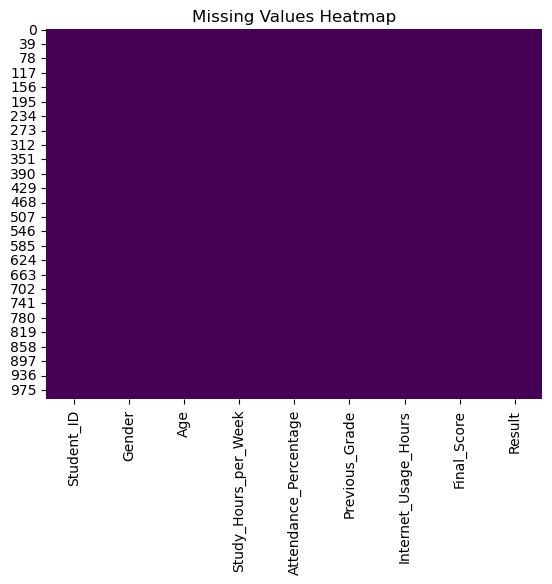

In [2]:
####################################    
# Step 2: Identify Missing Values
####################################

# Count missing values
print(df.isnull().sum())

# Percentage of missing values
missing_percentage = df.isnull().mean()*100
print(missing_percentage)

# Visualize missing values
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [14]:
####################################    
# Step 3: Handle Missing Values
####################################

df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Study_Hours_per_Week"] = df["Study_Hours_per_Week"].fillna(
    df["Study_Hours_per_Week"].median()
)

df["Attendance_Percentage"] = df["Attendance_Percentage"].fillna(
    df["Attendance_Percentage"].mean()
)

df["Previous_Grade"] = df["Previous_Grade"].fillna(
    df["Previous_Grade"].median()
)

df["Internet_Usage_Hours"] = df["Internet_Usage_Hours"].fillna(
    df["Internet_Usage_Hours"].median()
)

df["Final_Score"] = df["Final_Score"].fillna(
    df["Final_Score"].mean()
)

# Categorical Columns

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Result"] = df["Result"].fillna(df["Result"].mode()[0])

print("Handle Missing Values Successfully.... ")

Handle Missing Values Successfully.... 


In [17]:
####################################    
# Step 4: Detect and Remove Outliers
####################################

Q1 = df["Final_Score"].quantile(0.25)
Q3 = df["Final_Score"].quantile(0.75)

IQR = Q3 - Q1

df = df[~((df["Final_Score"] < (Q1 - 1.5*IQR)) | 
          (df["Final_Score"] > (Q3 + 1.5*IQR)))]


####################################    
# Step 5: Handle Duplicate Data
####################################

# Count duplicates
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Handle Duplicate Data Successfull... ")

0
Handle Duplicate Data Successfull... 


In [25]:
####################################    
# Step 6: Fix Data Inconsistency
####################################

# Standardize Gender column
df["Gender"] = df["Gender"].str.lower().str.strip()

df["Result"] = df["Result"].str.lower().str.strip()

# replace inconsistent values
df["Gender"] = df["Gender"].replace({
    "m": "male",
    "f": "female"
})

df["Result"] = df["Result"].replace({
    "pass": "pass",
    "fail": "fail"
})


print("Fix Data Inconsistency Sucessfull...")

Fix Data Inconsistency Sucessfull...


In [24]:
####################################    
# Step 7: Check Data Types
####################################

print(df.dtypes)

df["Age"] = df["Age"].astype(int)

df["Final_Score"] = df["Final_Score"].astype(float)

# Final Clean Dataset Save
df.to_csv("clean_student_data.csv", index=False)

print("Data Cleaning Completed Successfully")

Student_ID                 int64
Gender                    object
Age                        int64
Study_Hours_per_Week       int64
Attendance_Percentage      int64
Previous_Grade             int64
Internet_Usage_Hours       int64
Final_Score              float64
Result                    object
dtype: object
Data Cleaning Completed Successfully
